<a href="https://colab.research.google.com/github/dudanobree26/programa-generation-AD-2/blob/main/visualiza%C3%A7%C3%A3o_e_armazenamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# import de bibliotecas
import pandas as pd

In [ ]:
# ler os três arquivos

jan= pd.read_csv('/content/vendas_janeiro.csv')
fev= pd.read_csv('/content/vendas_fevereiro.csv')
mar= pd.read_csv('/content/vendas_marco.csv')

print(jan)

In [14]:
# transformar em dados
df_jan= pd.DataFrame(jan)
df_fev= pd.DataFrame(fev)
df_mar= pd.DataFrame(mar)

In [16]:
#concatenar
df_trimestre_completo= pd.concat([df_jan, df_fev, df_mar], ignore_index=False)

In [20]:
#criar o arquivo

df_trimestre_completo.to_csv('trimestre_completo.csv', index=False)


In [ ]:
 #KPI -> Key Performance Indicator (em português, Indicador-Chave de Performance)
display(df_trimestre_completo)

In [ ]:
#faturamento bruto

In [28]:
faturamento_bruto = df_trimestre_completo['Valor Total'].sum()
print(f"Faturamento Bruto do Trimestre: R$ {faturamento_bruto:,.2f}")

Faturamento Bruto do Trimestre: R$ 2,233,098.00


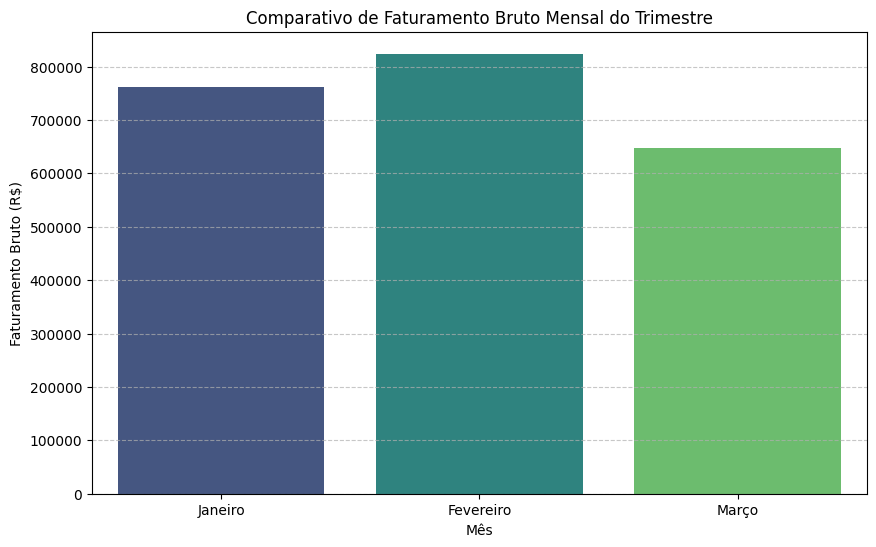

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotar o gráfico de barras do faturamento bruto mensal
plt.figure(figsize=(10, 6))
sns.barplot(x='Mes_Nome', y='Valor Total', data=faturamento_mensal, hue='Mes_Nome', palette='viridis', legend=False)
plt.title('Comparativo de Faturamento Bruto Mensal do Trimestre')
plt.xlabel('Mês')
plt.ylabel('Faturamento Bruto (R$)')
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Ticket Médio

In [30]:
ticket_medio = df_trimestre_completo['Valor Total'].mean()
print(f"Ticket Médio por transação: R$ {ticket_medio:,.2f}")

Ticket Médio por transação: R$ 13,533.93


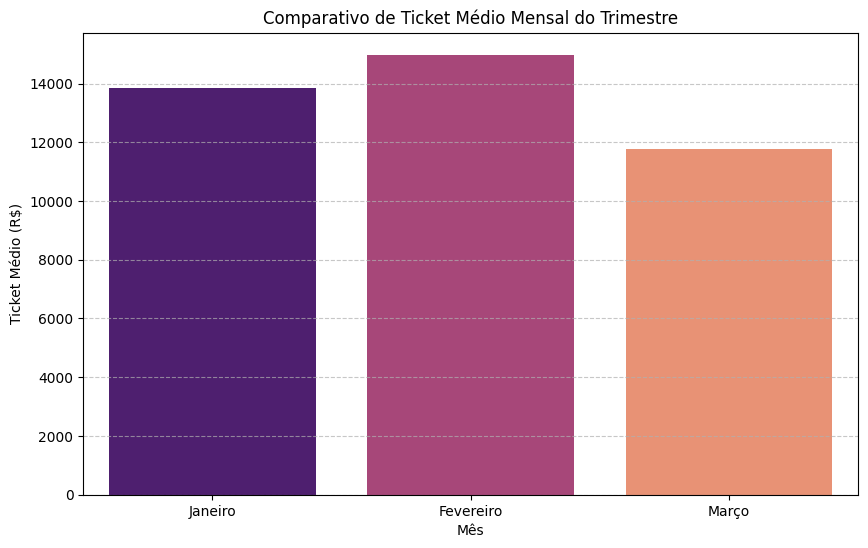

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Certificar-se de que a coluna 'Data' está no formato datetime
df_trimestre_completo['Data'] = pd.to_datetime(df_trimestre_completo['Data'])

# Criar uma coluna 'Mes' para o mês de cada transação
df_trimestre_completo['Mes'] = df_trimestre_completo['Data'].dt.month

# Calcular o ticket médio mensal
ticket_medio_mensal = df_trimestre_completo.groupby('Mes')['Valor Total'].mean().reset_index()

# Adicionar nomes dos meses para melhor visualização
mes_nomes = {
    1: 'Janeiro',
    2: 'Fevereiro',
    3: 'Março'
}
ticket_medio_mensal['Mes_Nome'] = ticket_medio_mensal['Mes'].map(mes_nomes)

# Plotar o gráfico de barras do ticket médio mensal
plt.figure(figsize=(10, 6))
sns.barplot(x='Mes_Nome', y='Valor Total', data=ticket_medio_mensal, hue='Mes_Nome', palette='magma', legend=False)
plt.title('Comparativo de Ticket Médio Mensal do Trimestre')
plt.xlabel('Mês')
plt.ylabel('Ticket Médio (R$)')
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Top Seller

In [32]:
top_seller_receita = df_trimestre_completo.groupby('Produto')['Valor Total'].sum().nlargest(1)
print("Top Seller (Receita):")
print(top_seller_receita)

Top Seller (Receita):
Produto
Amplificador 50W    399229
Name: Valor Total, dtype: int64


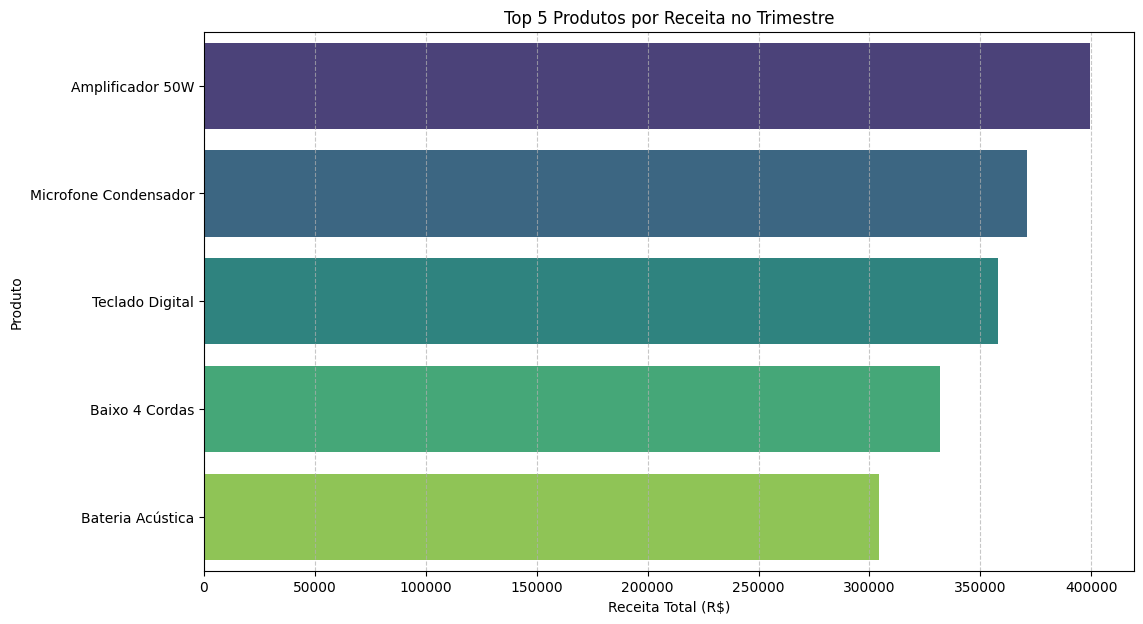

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular a receita total por produto
receita_por_produto = df_trimestre_completo.groupby('Produto')['Valor Total'].sum().reset_index()

# Obter os 5 produtos com maior receita
top_5_produtos_receita = receita_por_produto.nlargest(5, 'Valor Total')

# Plotar o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='Valor Total', y='Produto', data=top_5_produtos_receita, palette='viridis', hue='Produto', legend=False)
plt.title('Top 5 Produtos por Receita no Trimestre')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Produto')
plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Ranking Regional

In [34]:
# Ranking Regional por Desempenho (Receita) de unidade física
ranking_regional = df_trimestre_completo.groupby('Loja')['Valor Total'].sum().sort_values(ascending=False).reset_index()
print("Ranking Regional por Receita:")
print(ranking_regional)

Ranking Regional por Receita:
             Loja  Valor Total
0       São Paulo       685366
1        Curitiba       572846
2  Rio de Janeiro       566308
3  Belo Horizonte       408578


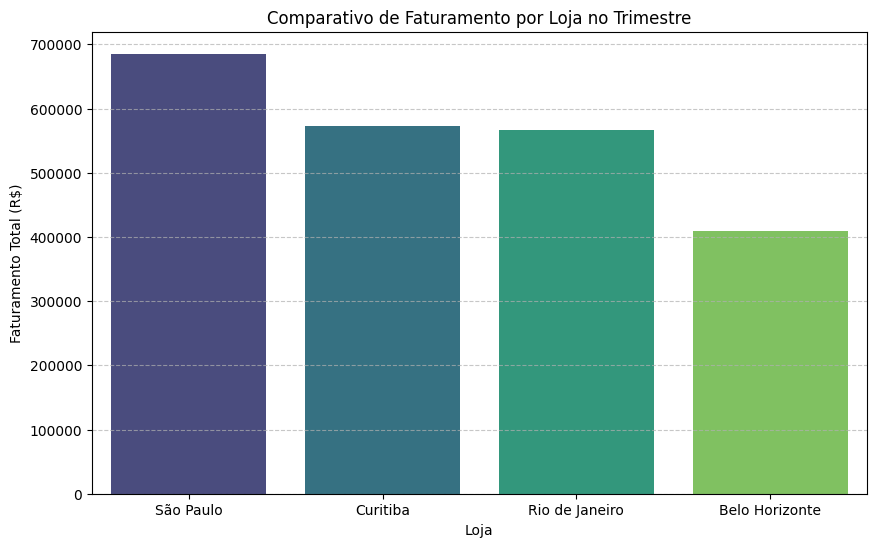

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotar o gráfico de barras do faturamento por loja
plt.figure(figsize=(10, 6))
sns.barplot(x='Loja', y='Valor Total', data=ranking_regional, palette='viridis', hue='Loja', legend=False)
plt.title('Comparativo de Faturamento por Loja no Trimestre')
plt.xlabel('Loja')
plt.ylabel('Faturamento Total (R$)')
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()